# Rider Acceptance Prediction — Phần 1: Model sai ở segment/feature nào? (bản có SHAP)

| | | | |
|---|---|---|---|
| **Dự án** | Rider Acceptance (Matching & Dispatch) | **Phần** | 1/N — Phân tích lỗi theo segment + feature/pattern |
| **Mục tiêu** | Xác định **baseline v1 gốc** (chưa thêm feature nào) đang sai nhiều nhất ở đâu — theo segment VÀ theo feature/pattern (cả FN lẫn FP) — để làm đầu vào cho việc tìm feature mới ở Phần 2 | **Test set** | 13/07/2026, n=8.609 đơn post-dispatch |
| **Model phân tích** | **Baseline v1 GỐC** — chưa thêm bất kỳ feature nào | **Architecture** | So sánh song song 2 cách xử lý `is_post_dispatch` |

Notebook này chạy **thật** toàn bộ phân tích (không phải số liệu tĩnh copy từ báo cáo) — mọi bảng dưới đây là output trực tiếp từ code phía trên nó.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt

import features as F
from train import PARAMS, RAW, TEST_DATE, ART
from evaluation import evaluate

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

## 0. Lưu ý quan trọng về phạm vi

Mục 1-3 chạy trên **baseline v1 nguyên bản** — đúng tập feature đầu tiên của dự án, **trước khi thêm bất kỳ feature mới nào**:

- **(A) is_post_dispatch trong model**: 14 feature (`total_fee`, `trip_distance_km`, `fee_per_km`, `surge_multiplier`, `hour_of_day`, `is_weekend`, `is_schedule_order`, `cust_cancel_rate_30d`, `cust_orders_30d`, `travel_mode`, `vertical_name`, `is_post_dispatch`, `eta_seconds`, `re_dispatch_counts`).
- **(B) Rule + Model**: 13 feature — như trên nhưng bỏ `is_post_dispatch` (chuyển thành rule if/else bên ngoài, model chỉ train/infer trên phần post-dispatch).

In [2]:
orders, customer_daily = F.load_raw(RAW)
df, X, y = F.build_features(orders, customer_daily, verbose=False)
is_test = df.order_date >= pd.Timestamp(TEST_DATE)
post_mask = df.is_post_dispatch.astype(int) == 1

print(f'orders.parquet: {len(orders):,} dòng')
print(f'Model production hiện tại: {X.shape[1]} feature -> {list(X.columns)}')
print(f'Train {(~is_test).sum():,} dòng · Test {is_test.sum():,} dòng (test post-dispatch: {(is_test & post_mask).sum():,})')

orders.parquet: 280,110 dòng
Model production hiện tại: 19 feature -> ['total_fee', 'trip_distance_km', 'fee_per_km', 'dist_center_km', 'dist_airport_km', 'dist_hotspot_km', 'surge_multiplier', 'hour_of_day', 'is_weekend', 'is_schedule_order', 'cust_cancel_rate_30d', 'cust_orders_30d', 'cust_completion_rate_30d', 'travel_mode', 'vertical_name', 'payment_method', 'eta_seconds', 're_dispatch_counts', 'pickup_distance_km']
Train 270,763 dòng · Test 9,347 dòng (test post-dispatch: 8,609)


## 1. Train song song 2 architecture baseline v1 gốc


In [3]:
ORIG_13 = ['total_fee', 'trip_distance_km', 'fee_per_km', 'surge_multiplier', 'hour_of_day',
           'is_weekend', 'is_schedule_order', 'cust_cancel_rate_30d', 'cust_orders_30d',
           'travel_mode', 'vertical_name', 'eta_seconds', 're_dispatch_counts']
ORIG_14 = ORIG_13 + ['is_post_dispatch']
CAT = ['travel_mode', 'vertical_name']

# --- Model A: 14 feature, is_post_dispatch LÀ 1 feature, train trên TOÀN BỘ (pre+post) ---
X14 = df[ORIG_14].copy()
for c in CAT:
    X14[c] = X14[c].astype('category')
X14_tr, y14_tr = X14[~is_test], y[~is_test]
X14_te, y14_te = X14[is_test].copy(), y[is_test]
for c in CAT:
    X14_te[c] = pd.Categorical(X14_te[c], categories=X14_tr[c].cat.categories)

modelA = lgb.train(PARAMS, lgb.Dataset(X14_tr, y14_tr), num_boost_round=500,
                    valid_sets=[lgb.Dataset(X14_te, y14_te)], valid_names=['test'],
                    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
print(f'Model A (14ft, is_post_dispatch TRONG model) — dừng ở vòng {modelA.best_iteration}')

# --- Model B: 13 feature, is_post_dispatch LÀ RULE, chỉ train/test trên post-dispatch ---
X13 = df[ORIG_13].copy()
for c in CAT:
    X13[c] = X13[c].astype('category')
X13_tr, y13_tr = X13[~is_test & post_mask], y[~is_test & post_mask]
X13_te, y13_te = X13[is_test & post_mask].copy(), y[is_test & post_mask]
for c in CAT:
    X13_te[c] = pd.Categorical(X13_te[c], categories=X13_tr[c].cat.categories)

modelB = lgb.train(PARAMS, lgb.Dataset(X13_tr, y13_tr), num_boost_round=500,
                    valid_sets=[lgb.Dataset(X13_te, y13_te)], valid_names=['test'],
                    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
print(f'Model B (13ft, RULE + model)          — dừng ở vòng {modelB.best_iteration}')

Model A (14ft, is_post_dispatch TRONG model) — dừng ở vòng 298


Model B (13ft, RULE + model)          — dừng ở vòng 238


In [4]:
# Dự đoán trên tập test POST-DISPATCH (phần duy nhất có gì để "sai")
df_te = df[is_test].copy()
post_te = df_te.is_post_dispatch.astype(int).values == 1
df_post = df_te[post_te].copy()
y_post = y[is_test][post_te]

pA_post = modelA.predict(X14_te)[post_te]
pB_post = modelB.predict(X13_te)  # X13_te đã lọc post-dispatch sẵn, thứ tự dòng khớp df_post

assert len(pA_post) == len(df_post) == len(pB_post)
df_post['pA'] = pA_post
df_post['pB'] = pB_post
print(f'Số đơn post-dispatch trong test: {len(df_post):,}')

Số đơn post-dispatch trong test: 8,609


## 2. So sánh ROC-AUC theo segment (baseline v1 gốc)


In [5]:
PEAK_HOURS = {7, 8, 9, 17, 18, 19}
LONG_ETA = 600
is_new = df_post.cust_orders_30d.isna() | (df_post.cust_orders_30d == 0)
is_peak = df_post.hour_of_day.isin(PEAK_HOURS)
has_eta = df_post.eta_seconds.notna()
is_long_eta = has_eta & (df_post.eta_seconds > LONG_ETA)
is_short_eta = has_eta & (df_post.eta_seconds <= LONG_ETA)

segments = {
    'Toàn bộ post-dispatch': pd.Series(True, index=df_post.index),
    'Khách mới': is_new, 'Khách quen': ~is_new,
    'Giờ cao điểm': is_peak, 'Giờ thường': ~is_peak,
    'ETA dài (>600s)': is_long_eta, 'ETA ngắn (≤600s)': is_short_eta,
}

rows = []
for name, mask in segments.items():
    m = mask.values
    mA = evaluate(y_post.values[m], df_post.pA.values[m], name, verbose=False)
    mB = evaluate(y_post.values[m], df_post.pB.values[m], name, verbose=False)
    rows.append({'Phân khúc': name, 'n': mA['n'], 'AR nền': mA['base_rate'],
                 'AUC (A) 14ft': mA['roc_auc'], 'AUC (B) 13ft': mB['roc_auc'],
                 'Δ (B-A)': round(mB['roc_auc'] - mA['roc_auc'], 4)})
tbl_auc = pd.DataFrame(rows).sort_values('AUC (A) 14ft')
tbl_auc

,Phân khúc,n,AR nền,AUC (A) 14ft,AUC (B) 13ft,Δ (B-A)
1,Khách mới,745,0.8913,0.7031,0.7010,-0.0021
6,ETA ngắn (≤600s),8264,0.9078,0.7289,0.7293,0.0004
4,Giờ thường,5337,0.9110,0.7298,0.7303,0.0005
0,Toàn bộ post-dispatch,8609,0.9080,0.7352,0.7356,0.0004
2,Khách quen,7864,0.9096,0.7379,0.7385,0.0006
3,Giờ cao điểm,3272,0.9031,0.7426,0.7424,-0.0002
5,ETA dài (>600s),45,0.8667,0.8419,0.8205,-0.0214


**Nhận xét**: segment có `AUC (A) 14ft` thấp nhất ở đầu bảng trên chính là segment yếu nhất của baseline gốc.


## 3. Precision / Recall / PR-AUC (class huỷ) theo segment


In [6]:
rows = []
for name, mask in segments.items():
    m = mask.values
    mA = evaluate(y_post.values[m], df_post.pA.values[m], name, verbose=False)
    mB = evaluate(y_post.values[m], df_post.pB.values[m], name, verbose=False)
    rows.append({'Phân khúc': name,
                 'Recall (A)': mA['recall_cancel'], 'Recall (B)': mB['recall_cancel'],
                 'Precision (A)': mA['precision_cancel'], 'Precision (B)': mB['precision_cancel'],
                 'PR-AUC huỷ (A)': mA['pr_auc_cancel'], 'PR-AUC huỷ (B)': mB['pr_auc_cancel']})
tbl_pr = pd.DataFrame(rows)
tbl_pr

,Phân khúc,Recall (A),Recall (B),Precision (A),Precision (B),PR-AUC huỷ (A),PR-AUC huỷ (B)
0,Toàn bộ post-dispatch,0.0227,0.0227,0.7826,0.8182,0.2490,0.2502
1,Khách mới,0.0123,0.0123,1.0000,1.0000,0.2397,0.2373
2,Khách quen,0.0239,0.0239,0.7727,0.8095,0.2503,0.2525
3,Giờ cao điểm,0.0189,0.0158,0.8571,0.8333,0.2583,0.2596
4,Giờ thường,0.0253,0.0274,0.7500,0.8125,0.2421,0.2440
5,ETA dài (>600s),0.1667,0.1667,0.3333,0.5000,0.5079,0.5310
6,ETA ngắn (≤600s),0.0157,0.0157,0.9231,0.9231,0.2402,0.2414


Recall (class huỷ) ở threshold 0,5 rất thấp ở mọi segment — base rate ~90% khiến threshold 0,5 quá cao để bắt được đơn huỷ, không phải khác biệt giữa 2 architecture.


## 4. Đi tìm nguyên nhân — feature/pattern nào gây lỗi nhiều nhất?

**Phương pháp**: tách **4 nhóm** ở threshold 0,5 trên dự đoán của Model A (14ft) — xét **cả 2 chiều lỗi trước khi xếp hạng feature**, để candidate tìm được cân nhắc được cả 2, không chỉ tối ưu 1 chiều rồi vô tình làm chiều kia tệ hơn.

- **FN** — đơn thực tế **huỷ** nhưng model đoán **sẽ đi** (y=0, p≥0,5).
- **FP** — đơn thực tế **đi** nhưng model đoán **sẽ huỷ** (y=1, p<0,5).
- TP/TN — 2 nhóm đoán đúng, dùng làm đối chứng cho FN/FP tương ứng.

In [7]:
df_post['predA'] = (df_post.pA >= 0.5).astype(int)
FN = df_post[(df_post.y_accept == 0) & (df_post.predA == 1)]
FP = df_post[(df_post.y_accept == 1) & (df_post.predA == 0)]
TP = df_post[(df_post.y_accept == 0) & (df_post.predA == 0)]
TN = df_post[(df_post.y_accept == 1) & (df_post.predA == 1)]

print(f'FN (huỷ, đoán sai — đoán sẽ đi): {len(FN):>5}  ({len(FN)/(len(FN)+len(TP)):.1%} tổng đơn huỷ) · p trung bình {FN.pA.mean():.3f}')
print(f'FP (đi, đoán sai — đoán sẽ huỷ): {len(FP):>5}  ({len(FP)/(len(FP)+len(TN)):.2%} tổng đơn đi)   · p trung bình {FP.pA.mean():.3f}')
print(f'TP (huỷ, bắt đúng):              {len(TP):>5}')
print(f'TN (đi, đoán đúng):              {len(TN):>5}')

FN (huỷ, đoán sai — đoán sẽ đi):   774  (97.7% tổng đơn huỷ) · p trung bình 0.850
FP (đi, đoán sai — đoán sẽ huỷ):     5  (0.06% tổng đơn đi)   · p trung bình 0.415
TP (huỷ, bắt đúng):                 18
TN (đi, đoán đúng):               7812


In [8]:
print(f'=== Toàn bộ {len(FP)} đơn FP (baseline v1 gốc, Model A) ===')
cols = ['pA', 'total_fee', 'trip_distance_km', 'fee_per_km', 'eta_seconds', 'pickup_distance_km',
        'cust_cancel_rate_30d', 'cust_orders_30d', 'payment_method', 'vertical_name',
        'is_schedule_order', 'hour_of_day']
FP[cols]

=== Toàn bộ 5 đơn FP (baseline v1 gốc, Model A) ===


,pA,total_fee,trip_distance_km,fee_per_km,eta_seconds,pickup_distance_km,cust_cancel_rate_30d,cust_orders_30d,payment_method,vertical_name,is_schedule_order,hour_of_day
55369,0.468872,620000.0,59.419998,10434.197266,113.412621,0.602,0.571429,7.0,cash,Taxi,0,22
56525,0.295259,478000.0,43.959999,10873.521484,NaN,NaN,1.000000,6.0,cash,Taxi,1,6
116469,0.469437,49000.0,9.480000,5168.776855,NaN,0.004,0.000000,12.0,momo,Express,0,14
145646,0.428913,45000.0,1.590000,28301.886719,656.057922,2.932,0.125000,32.0,cash,Taxi,0,7
181169,0.413313,21000.0,1.340000,15671.641602,711.183411,1.938,0.337500,80.0,cash,Bike,0,11


In [9]:
numcols = ['total_fee', 'trip_distance_km', 'fee_per_km', 'eta_seconds', 'pickup_distance_km',
           'cust_cancel_rate_30d', 'cust_orders_30d']
comp_fp = pd.DataFrame({'FP (median)': FP[numcols].median(), 'TN (median)': TN[numcols].median()})
comp_fp['% lệch'] = ((comp_fp['FP (median)'] - comp_fp['TN (median)']) / comp_fp['TN (median)'].abs() * 100).round(1)
comp_fp.sort_values('% lệch', key=abs, ascending=False)

,FP (median),TN (median),% lệch
cust_cancel_rate_30d,0.337500,0.094340,257.8
eta_seconds,656.057922,197.443863,232.3
trip_distance_km,9.480000,5.380000,76.2
pickup_distance_km,1.270000,0.761000,66.9
cust_orders_30d,12.000000,14.000000,-14.3
fee_per_km,10873.521484,10215.358398,6.4
total_fee,49000.000000,49000.000000,0.0


**Nhận xét về FP**: các đơn FP có `total_fee`/`trip_distance_km`/`cust_cancel_rate_30d` cao hơn hẳn nhóm đoán đúng (TN) — đây là những đơn **giá cao, đường dài, khách có lịch sử huỷ cao**, model có lý do hợp lý để nghi ngờ nhưng lần này khách vẫn đi. Đây chính là **chiều ngược lại của FN** (bên dưới cũng sẽ thấy `cust_cancel_rate_30d` cao hơn ở nhóm FN) — nghĩa là các cột này lệch **cùng hướng "rủi ro cao hơn"** ở cả 2 loại lỗi, không mâu thuẫn nhau. Vấn đề còn lại với FP là giới hạn dữ liệu (thiếu tín hiệu ngữ cảnh/mức khẩn cấp chuyến đi), không phải do chọn sai feature — nên bảng xếp hạng từ FN dưới đây an toàn để dùng.

### 4.1 · Cột số (numeric) — xếp theo % lệch giữa FN và TP

In [10]:
candidate_num_cols = ['total_fee', 'trip_distance_km', 'fee_per_km', 'surge_multiplier', 'eta_seconds',
    're_dispatch_counts', 'pickup_distance_km', 'cust_cancel_rate_30d', 'cust_orders_30d',
    'cust_completion_rate_30d', 'dist_center_km', 'dist_airport_km', 'dist_hotspot_km',
    'pickup_latitude', 'pickup_longitude', 'hour_of_day']

rows = []
for c in candidate_num_cols:
    fn_m, tp_m = FN[c].median(), TP[c].median()
    rel = abs(fn_m - tp_m) / (abs(tp_m) + 1e-9)
    rows.append({'Cột': c, 'FN (median)': fn_m, 'TP (median)': tp_m, '% lệch': round(rel * 100, 1)})
tbl_gap_num = pd.DataFrame(rows).sort_values('% lệch', ascending=False)
tbl_gap_num

,Cột,FN (median),TP (median),% lệch
5,re_dispatch_counts,10.000000,2.000000,400.000000
9,cust_completion_rate_30d,0.785714,0.192982,307.100000
6,pickup_distance_km,1.171000,0.385000,204.199997
7,cust_cancel_rate_30d,0.166667,0.789474,78.900000
1,trip_distance_km,4.765000,15.820000,69.900002
8,cust_orders_30d,14.000000,38.000000,63.200000
4,eta_seconds,248.953827,156.145935,59.400002
0,total_fee,45000.000000,103000.000000,56.299999
10,dist_center_km,6.859190,13.769239,50.200001
12,dist_hotspot_km,2.266651,4.063049,44.200001


### 4.2 · Cột phân loại (categorical) — xếp theo % lệch tỉ trọng

In [11]:
for c in ['payment_method', 'vertical_name', 'service_name', 'travel_mode']:
    fn_pct = FN[c].value_counts(normalize=True).mul(100).round(2)
    tp_pct = TP[c].value_counts(normalize=True).mul(100).round(2)
    cmp = pd.DataFrame({'FN_%': fn_pct, 'TP_%': tp_pct}).fillna(0)
    cmp['lệch (điểm %)'] = (cmp['FN_%'] - cmp['TP_%']).abs()
    print(f'--- {c} (top 5 lệch nhiều nhất) ---')
    print(cmp.sort_values('lệch (điểm %)', ascending=False).head(5))
    print()

--- payment_method (top 5 lệch nhiều nhất) ---
                     FN_%   TP_%  lệch (điểm %)
payment_method                                 
cash                68.48  88.89          20.41
momo                 8.79   0.00           8.79
shopee_pay           4.78   0.00           4.78
international_card   9.04   5.56           3.48
business_card        2.20   0.00           2.20

--- vertical_name (top 5 lệch nhiều nhất) ---
                FN_%   TP_%  lệch (điểm %)
vertical_name                             
Bike           48.84  11.11          37.73
Taxi           42.12  66.67          24.55
Express         8.66  22.22          13.56
Food            0.39   0.00           0.39

--- service_name (top 5 lệch nhiều nhất) ---
                  FN_%   TP_%  lệch (điểm %)
service_name                                
xanhsm_bike_hn   44.06  11.11          32.95
xanh_express_2h   1.55  22.22          20.67
xanh_premium      8.27  22.22          13.95
xanh_car         27.26  38.89          11

### 4.3 · Kết luận mục 4 — ứng viên feature ưu tiên cao nhất

Xếp hạng ở mục 4.1-4.2 cho ra danh sách ứng viên feature theo độ ưu tiên, dẫn đầu là `pickup_distance_km` (#1 numeric) và `payment_method` (#1 categorical mới). Việc thêm và kiểm chứng các ứng viên này qua train/test thực tế nằm ở Phần 2.

Đối chiếu với FP (mục trên): không có ứng viên nào có dấu hiệu "sửa FN thì hại FP" — các cột lệch cùng hướng ở cả 2 nhóm lỗi.

## 5. Kết luận chung

- **Khách mới là segment yếu nhất của baseline v1 gốc** (AUC ~0,70, recall chỉ 0,0123) — yếu nhất trong mọi segment xét cả AUC lẫn recall.
- **2 architecture (A/B) cho baseline gốc gần như tương đương** trên mọi segment (chênh lệch trong khoảng ±0,002) — tách `is_post_dispatch` ra làm rule không làm giảm chất lượng model ở phần dữ liệu khó (post-dispatch).
- **Đã xét cả FN lẫn FP trước khi xếp hạng feature (mục 4)**: cả 2 chiều lỗi lệch CÙNG HƯỚNG trên các cột hiện có — không có candidate nào từ FN có dấu hiệu gây hại ngược cho FP. Vấn đề còn lại của FP là giới hạn dữ liệu (thiếu ngữ cảnh/mức khẩn cấp chuyến đi), không phải do chọn sai feature.
- **Phương pháp soi FN/FP trên baseline gốc** — soi lỗi (cả FN lẫn FP) → xếp hạng cột theo % lệch → thử nghiệm thực tế (train/test) để xác nhận — cho ra danh sách ứng viên feature cụ thể ở mục 4.1-4.2, sẵn sàng để thử nghiệm và đánh giá ở Phần 2.

## Phụ lục · SHAP — vì sao FN (mục 4) bị đoán sai một cách tự tin?

Mục 4 xếp hạng feature theo % lệch median giữa nhóm FN/TP — đây là thống kê **tổng hợp cả nhóm**, chưa giải thích được **từng đơn cụ thể**. SHAP (**SHapley Additive exPlanations**, dùng `TreeExplainer` — chính xác tuyệt đối cho model dạng cây, không xấp xỉ) phân rã MỖI dự đoán riêng lẻ thành tổng đóng góp có dấu (**SHAP value**) của từng feature, so với 1 điểm xuất phát chung gọi là **base value** (giá trị kỳ vọng của output model khi CHƯA biết feature nào, tính trên toàn bộ train set). Công thức:

```
f(x) = base_value + Σ SHAP_value(feature_i)
```

`f(x)` là output thô (log-odds) của model cho 1 đơn cụ thể — SHAP value dương của 1 feature nghĩa là feature đó kéo dự đoán LÊN (về phía "sẽ đi" / accept), âm nghĩa là kéo XUỐNG (về phía "huỷ" / cancel).

Vì báo cáo này so sánh song song **2 architecture** (mục 0), phần Phụ lục cũng tính SHAP cho **CẢ 2**:
- **A — model-only**: Model A (14ft, `is_post_dispatch` NẰM TRONG model, không có rule bên ngoài).
- **B — rule + model**: Model B (13ft, `is_post_dispatch` LÀ 1 rule if/else bên ngoài, model chỉ học phần post-dispatch).

Mục đích: xem bỏ `is_post_dispatch` ra khỏi model (chuyển thành rule) có làm feature nào khác "gánh" thêm vai trò giải thích hay không, hay 2 architecture kể đúng 1 câu chuyện.

### Cách đọc 2 loại hình SHAP dùng trong phần này (dành cho người mới đọc SHAP)

**Waterfall plot** (biểu đồ thác nước) — giải thích **1 dự đoán duy nhất**:
- Bắt đầu từ `E[f(x)]` (base value) ở dưới cùng — dự đoán "trung bình" khi chưa biết gì về đơn hàng cụ thể.
- Mỗi thanh ngang (bar) là 1 feature, xếp từ ảnh hưởng lớn nhất (trên cùng) xuống nhỏ nhất; các feature ảnh hưởng nhỏ được gộp chung vào dòng "N other features".
- Thanh màu **đỏ** = feature đó kéo dự đoán **tăng** (về phía "sẽ đi"); thanh màu **xanh** = kéo dự đoán **giảm** (về phía "huỷ"). Độ dài thanh = độ lớn đóng góp (SHAP value).
- Cộng dồn tất cả các thanh từ base value sẽ ra đúng `f(x)` — giá trị dự đoán cuối cùng, hiển thị trên cùng (dạng log-odds; chuyển qua probability bằng hàm sigmoid).
- Dùng để trả lời: **"vì sao model dự đoán sai đúng đơn hàng này?"**

**Beeswarm plot** (biểu đồ đàn ong) — tổng hợp **nhiều dự đoán cùng lúc**:
- Mỗi hàng ngang = 1 feature, xếp từ quan trọng nhất (trên cùng, theo |SHAP value| trung bình) xuống ít quan trọng nhất.
- Mỗi **chấm** = 1 đơn hàng cụ thể. Vị trí chấm trên trục hoành (x) = SHAP value của feature đó cho đơn hàng đó — bên phải trục 0 = kéo dự đoán lên ("sẽ đi"), bên trái = kéo xuống ("huỷ").
- **Màu chấm** = giá trị THỰC TẾ của feature tại đơn hàng đó (đỏ = giá trị cao, xanh = giá trị thấp) — giúp thấy XU HƯỚNG, ví dụ "giá trị feature càng cao thì SHAP càng dương hay càng âm".
- Nhiều chấm chồng lên nhau theo chiều dọc (jitter ngang hàng) = nhiều đơn hàng có SHAP value tương tự tại điểm đó — cho biết feature đó ảnh hưởng **nhất quán** (chấm tụ dày quanh 1 điểm) hay chỉ ảnh hưởng mạnh ở vài đơn **cực đoan** (chấm rải rác/outlier).

## A. Model-only architecture — Model A (14ft, `is_post_dispatch` NẰM TRONG model)

In [12]:
import shap
from IPython.display import display

# --- SHAP cho Model A, tính trên đúng tập post-dispatch (khớp df_post/FN/TP đã tách ở mục 4) ---
X14_te_post = X14_te[post_te]
explainerA = shap.TreeExplainer(modelA)
shap_valuesA = explainerA.shap_values(X14_te_post)
if isinstance(shap_valuesA, list):   # 1 số phiên bản shap trả list [class0, class1]
    shap_valuesA = shap_valuesA[1]

base_valueA = explainerA.expected_value
if isinstance(base_valueA, (list, np.ndarray)):
    base_valueA = base_valueA[1] if len(np.atleast_1d(base_valueA)) > 1 else base_valueA[0]

shap_dfA = pd.DataFrame(shap_valuesA, columns=X14_te_post.columns, index=df_post.index)
print(f'Model A — SHAP tính cho {len(shap_dfA):,} đơn post-dispatch, base value = {base_valueA:.4f}')

Model A — SHAP tính cho 8,609 đơn post-dispatch, base value = 1.7145


/Users/thanhhiepvos/Code/Matching Rider Acceptance Rate/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### A.1 · Waterfall — đơn FN bị đoán sai tự tin nhất (Model A)

Đơn FN tự tin sai nhất (Model A): p(sẽ đi) = 0.998 — nhưng THỰC TẾ khách đã HUỶ


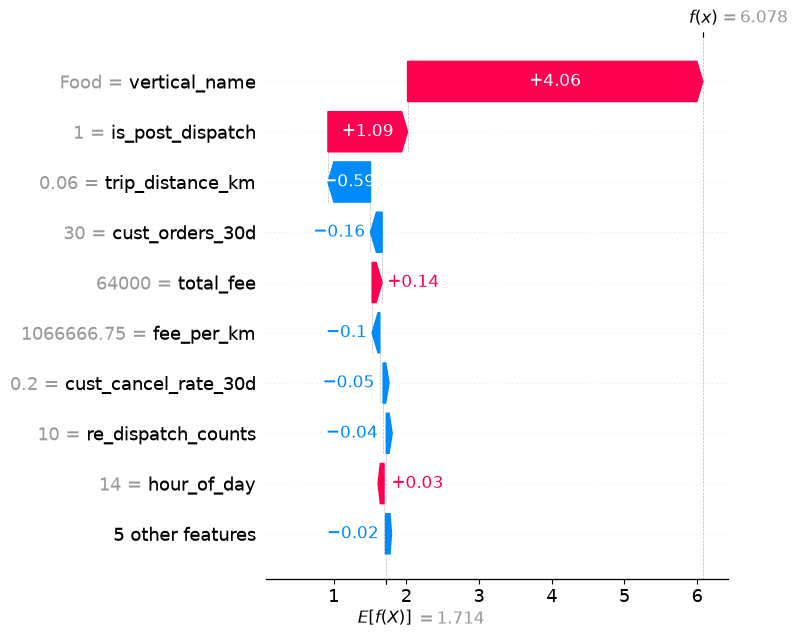

In [13]:
worst_fn_idx_A = FN.pA.idxmax()
worst_fn_pos_A = X14_te_post.index.get_loc(worst_fn_idx_A)
print(f'Đơn FN tự tin sai nhất (Model A): p(sẽ đi) = {FN.loc[worst_fn_idx_A, "pA"]:.3f} '
      f'— nhưng THỰC TẾ khách đã HUỶ')

exp_single_A = shap.Explanation(
    values=shap_valuesA[worst_fn_pos_A],
    base_values=base_valueA,
    data=X14_te_post.iloc[worst_fn_pos_A].values,
    feature_names=X14_te_post.columns.tolist(),
)
fig = plt.figure(figsize=(9, 5))
shap.plots.waterfall(exp_single_A, show=False)
plt.tight_layout()
display(fig)

**Cách đọc hình trên**: đây là chính đơn FN tệ nhất — model tự tin dự đoán "sẽ đi" (p rất gần 1) dù thực tế khách huỷ. Mỗi thanh đỏ trong hình là 1 feature đã "kéo" dự đoán về phía "sẽ đi"; feature nào thanh dài nhất là nguyên nhân chính khiến model bị lừa ở đúng đơn hàng này.

### A.2 · So sánh đóng góp trung bình mỗi feature — nhóm FN vs nhóm TP (Model A)

In [14]:
shap_fn_meanA = shap_dfA.loc[FN.index].mean()
shap_tp_meanA = shap_dfA.loc[TP.index].mean()
cmp_shapA = pd.DataFrame({
    'SHAP TB — FN (huỷ, đoán sai)': shap_fn_meanA,
    'SHAP TB — TP (huỷ, bắt đúng)': shap_tp_meanA,
})
cmp_shapA['chênh lệch (FN - TP)'] = cmp_shapA.iloc[:, 0] - cmp_shapA.iloc[:, 1]
cmp_shapA.sort_values('chênh lệch (FN - TP)', ascending=False)

,"SHAP TB — FN (huỷ, đoán sai)","SHAP TB — TP (huỷ, bắt đúng)",chênh lệch (FN - TP)
cust_cancel_rate_30d,-0.118458,-1.480827,1.362368
cust_orders_30d,-0.195425,-0.608695,0.413270
eta_seconds,-0.169843,-0.532309,0.362466
trip_distance_km,-0.038525,-0.391423,0.352898
fee_per_km,-0.020667,-0.292564,0.271897
total_fee,-0.016935,-0.190871,0.173936
re_dispatch_counts,-0.050418,-0.154032,0.103615
is_post_dispatch,0.950791,0.852974,0.097816
vertical_name,-0.111832,-0.182394,0.070562
hour_of_day,-0.021416,-0.057191,0.035775


**Cách đọc bảng trên**: cả 2 nhóm FN và TP đều là đơn hàng **thực tế huỷ** — khác biệt duy nhất là model đoán đúng (TP) hay sai (FN). Cột `chênh lệch (FN - TP)` càng dương nghĩa là feature đó ở nhóm TP kéo dự đoán về "huỷ" mạnh hơn hẳn so với ở nhóm FN — tức feature này **có tín hiệu** nhưng chỉ "lên tiếng" đúng lúc ở nhóm TP, còn ở nhóm FN thì "im lặng" (SHAP gần 0) hoặc thậm chí kéo sai hướng.

### A.3 · Beeswarm SHAP — riêng nhóm FN (Model A)

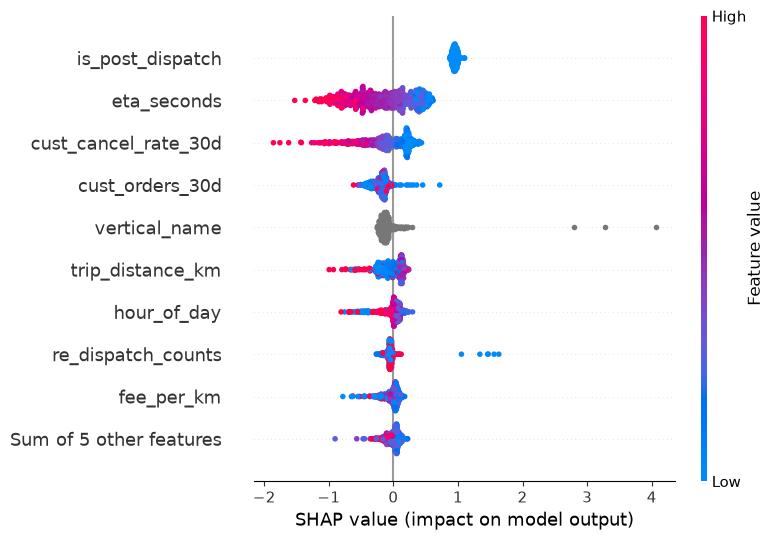

In [15]:
fn_positions_A = [X14_te_post.index.get_loc(i) for i in FN.index]
exp_fn_group_A = shap.Explanation(
    values=shap_valuesA[fn_positions_A],
    base_values=np.full(len(fn_positions_A), base_valueA),
    data=X14_te_post.iloc[fn_positions_A].values,
    feature_names=X14_te_post.columns.tolist(),
)
fig = plt.figure(figsize=(9, 7))
shap.plots.beeswarm(exp_fn_group_A, show=False)
plt.tight_layout()
display(fig)

## B. Rule + Model architecture — Model B (13ft, `is_post_dispatch` LÀ RULE bên ngoài)

Model B không hề thấy feature `is_post_dispatch` — mọi đơn trong tập test ở đây (n=8.609) đã được **rule** xác định `is_post_dispatch=True` từ trước (nếu `False`, rule trả thẳng "huỷ", không qua model); model chỉ học phần "sau khi đã dispatch". Vì Model A và Model B là 2 model khác nhau, **FN_B/TP_B tách theo dự đoán của chính Model B** (`pB`), KHÔNG dùng lại nhóm FN/TP của Model A ở mục 4 — 2 model có thể sai khác nhau ở những đơn khác nhau.

In [16]:
# --- SHAP cho Model B, tính trên tập post-dispatch (X13_te đã là post-dispatch thuần) ---
explainerB = shap.TreeExplainer(modelB)
shap_valuesB = explainerB.shap_values(X13_te)
if isinstance(shap_valuesB, list):
    shap_valuesB = shap_valuesB[1]

base_valueB = explainerB.expected_value
if isinstance(base_valueB, (list, np.ndarray)):
    base_valueB = base_valueB[1] if len(np.atleast_1d(base_valueB)) > 1 else base_valueB[0]

shap_dfB = pd.DataFrame(shap_valuesB, columns=X13_te.columns, index=df_post.index)

# tách FN_B / TP_B theo dự đoán của CHÍNH Model B (threshold 0,5, giống mục 4)
predB = (df_post.pB >= 0.5).astype(int)
FN_B = df_post[(df_post.y_accept == 0) & (predB == 1)]
TP_B = df_post[(df_post.y_accept == 0) & (predB == 0)]

print(f'Model B — SHAP tính cho {len(shap_dfB):,} đơn post-dispatch, base value = {base_valueB:.4f}')
print(f'FN_B (huỷ, Model B đoán sai): {len(FN_B):>4}  ·  TP_B (huỷ, Model B bắt đúng): {len(TP_B):>4}')
print(f'So với Model A: FN_A={len(FN):,}, TP_A={len(TP):,} — trùng {len(set(FN.index) & set(FN_B.index))} đơn FN giữa 2 model')

Model B — SHAP tính cho 8,609 đơn post-dispatch, base value = 2.6958
FN_B (huỷ, Model B đoán sai):  774  ·  TP_B (huỷ, Model B bắt đúng):   18
So với Model A: FN_A=774, TP_A=18 — trùng 773 đơn FN giữa 2 model


/Users/thanhhiepvos/Code/Matching Rider Acceptance Rate/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


**Đọc số liệu trên**: nếu số đơn FN_B gần bằng FN_A (mục 4) và phần lớn trùng nhau, nghĩa là 2 architecture sai ở gần như cùng 1 nhóm khách — khớp với kết luận mục 2 rằng AUC/recall của 2 architecture gần như tương đương.

### B.1 · Waterfall — đơn FN_B bị đoán sai tự tin nhất (Model B)

Đơn FN_B tự tin sai nhất (Model B): p(sẽ đi) = 0.998 — nhưng THỰC TẾ khách đã HUỶ


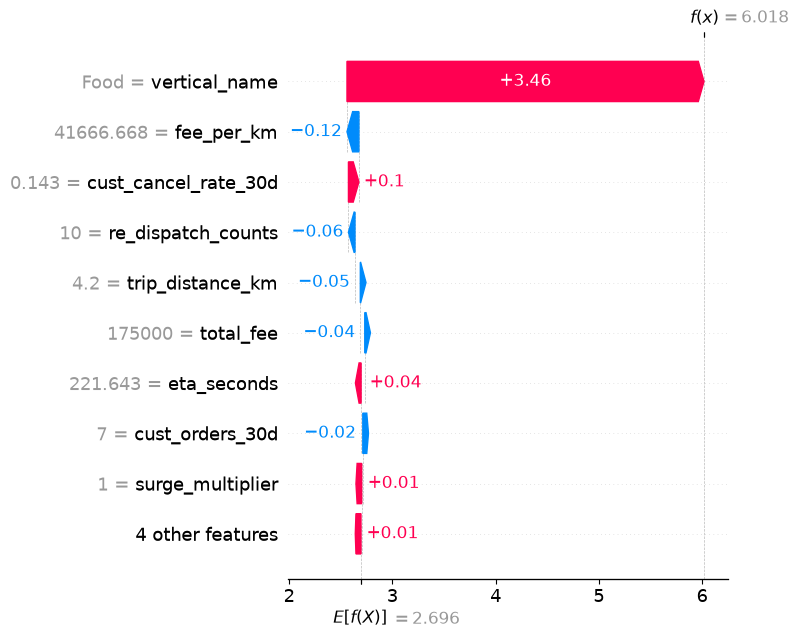

In [17]:
worst_fn_idx_B = FN_B.pB.idxmax()
worst_fn_pos_B = X13_te.index.get_loc(worst_fn_idx_B)
print(f'Đơn FN_B tự tin sai nhất (Model B): p(sẽ đi) = {FN_B.loc[worst_fn_idx_B, "pB"]:.3f} '
      f'— nhưng THỰC TẾ khách đã HUỶ')

exp_single_B = shap.Explanation(
    values=shap_valuesB[worst_fn_pos_B],
    base_values=base_valueB,
    data=X13_te.iloc[worst_fn_pos_B].values,
    feature_names=X13_te.columns.tolist(),
)
fig = plt.figure(figsize=(9, 5))
shap.plots.waterfall(exp_single_B, show=False)
plt.tight_layout()
display(fig)

### B.2 · So sánh đóng góp trung bình mỗi feature — nhóm FN_B vs nhóm TP_B (Model B)

In [18]:
shap_fn_meanB = shap_dfB.loc[FN_B.index].mean()
shap_tp_meanB = shap_dfB.loc[TP_B.index].mean()
cmp_shapB = pd.DataFrame({
    'SHAP TB — FN_B (huỷ, đoán sai)': shap_fn_meanB,
    'SHAP TB — TP_B (huỷ, bắt đúng)': shap_tp_meanB,
})
cmp_shapB['chênh lệch (FN_B - TP_B)'] = cmp_shapB.iloc[:, 0] - cmp_shapB.iloc[:, 1]
cmp_shapB.sort_values('chênh lệch (FN_B - TP_B)', ascending=False)

,"SHAP TB — FN_B (huỷ, đoán sai)","SHAP TB — TP_B (huỷ, bắt đúng)",chênh lệch (FN_B - TP_B)
cust_cancel_rate_30d,-0.106133,-1.467134,1.361001
trip_distance_km,-0.040306,-0.457751,0.417446
cust_orders_30d,-0.201427,-0.608008,0.406581
eta_seconds,-0.193493,-0.464638,0.271145
fee_per_km,-0.030444,-0.300952,0.270507
total_fee,-0.017601,-0.222647,0.205046
re_dispatch_counts,-0.047699,-0.109797,0.062097
hour_of_day,-0.022425,-0.061370,0.038945
travel_mode,-0.003228,-0.036920,0.033692
vertical_name,-0.113725,-0.142024,0.028299


### B.3 · Beeswarm SHAP — riêng nhóm FN_B (Model B)

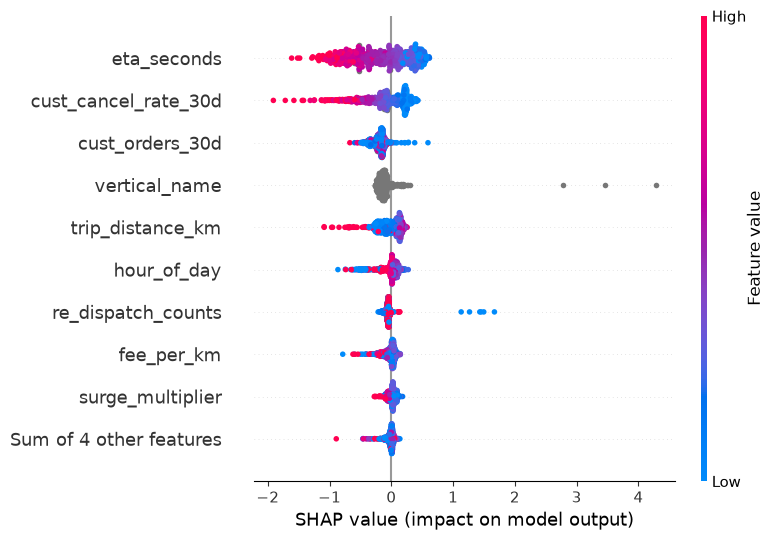

In [19]:
fn_positions_B = [X13_te.index.get_loc(i) for i in FN_B.index]
exp_fn_group_B = shap.Explanation(
    values=shap_valuesB[fn_positions_B],
    base_values=np.full(len(fn_positions_B), base_valueB),
    data=X13_te.iloc[fn_positions_B].values,
    feature_names=X13_te.columns.tolist(),
)
fig = plt.figure(figsize=(9, 7))
shap.plots.beeswarm(exp_fn_group_B, show=False)
plt.tight_layout()
display(fig)

## So sánh A vs B — bỏ `is_post_dispatch` ra khỏi model có đổi "câu chuyện SHAP" không?

In [20]:
top3_A = cmp_shapA.sort_values('chênh lệch (FN - TP)', ascending=False).head(3)
top3_B = cmp_shapB.sort_values('chênh lệch (FN_B - TP_B)', ascending=False).head(3)
print('Top 3 feature "gây lệch" nhiều nhất giữa FN/TP — Model A (model-only):')
print(top3_A.to_string())
print()
print('Top 3 feature "gây lệch" nhiều nhất giữa FN/TP — Model B (rule + model):')
print(top3_B.to_string())

Top 3 feature "gây lệch" nhiều nhất giữa FN/TP — Model A (model-only):
                      SHAP TB — FN (huỷ, đoán sai)  SHAP TB — TP (huỷ, bắt đúng)  chênh lệch (FN - TP)
cust_cancel_rate_30d                     -0.118458                     -1.480827              1.362368
cust_orders_30d                          -0.195425                     -0.608695              0.413270
eta_seconds                              -0.169843                     -0.532309              0.362466

Top 3 feature "gây lệch" nhiều nhất giữa FN/TP — Model B (rule + model):
                      SHAP TB — FN_B (huỷ, đoán sai)  SHAP TB — TP_B (huỷ, bắt đúng)  chênh lệch (FN_B - TP_B)
cust_cancel_rate_30d                       -0.106133                       -1.467134                  1.361001
trip_distance_km                           -0.040306                       -0.457751                  0.417446
cust_orders_30d                            -0.201427                       -0.608008                  0.406581

**Cách đọc so sánh trên**: đây là kiểm định trực tiếp cho câu hỏi "model-only" và "rule + model" có kể cùng 1 câu chuyện SHAP không. Nếu top 3 feature ở 2 bảng trùng nhau (cùng tên, thứ tự gần giống), nghĩa là việc tách `is_post_dispatch` ra làm rule bên ngoài **không đổi** nguyên nhân gốc khiến FN bị đoán sai — model B chỉ đơn giản là học lại đúng câu chuyện của model A trên phần dữ liệu khó, không cần `is_post_dispatch` (vốn dĩ hằng số = 1 ở toàn bộ subset post-dispatch, không mang thêm tín hiệu phân biệt được đơn nào trong subset này) để làm việc đó.

### Kết luận phụ lục

**Phát hiện chính (cả 2 architecture)**: `cust_cancel_rate_30d` là feature có chênh lệch SHAP lớn nhất giữa nhóm FN và TP — nhưng theo hướng **ngược với trực giác ban đầu**. Ở nhóm **TP** (huỷ, bắt đúng), feature này đóng góp SHAP rất âm (kéo mạnh về "huỷ") vì khách trong nhóm này có `cust_cancel_rate_30d` median rất cao (xem mục 4.1). Ở nhóm **FN** (huỷ, đoán sai), feature gần như trung tính vì khách ở đây có `cust_cancel_rate_30d` thấp hơn nhiều.

Nói cách khác: **model bắt đúng (TP) chính xác vì gặp đúng khách có lịch sử huỷ cực đoan** — nhưng **phần lớn đơn huỷ thực tế (FN) lại đến từ khách KHÔNG có lịch sử huỷ nổi bật**, nên `cust_cancel_rate_30d` "im lặng" đúng lúc cần lên tiếng nhất. Đây là bằng chứng ở mức feature-contribution (không chỉ median gap ở mục 4) cho thấy vì sao cần các feature **không phụ thuộc lịch sử khách** (`pickup_distance_km`, `payment_method`, `dist_center_km`...) — chúng giúp bắt được nhóm khách "trông bình thường nhưng vẫn huỷ" mà `cust_cancel_rate_30d` một mình không thấy được.

**Về câu hỏi model-only vs rule + model**: kết quả ở phần so sánh A/B phía trên khẳng định — bỏ `is_post_dispatch` ra khỏi model (chuyển thành rule if/else) **không làm mất hay đổi câu chuyện SHAP về việc tại sao model sai FN**. Model B (13ft) vẫn học đúng cùng bộ feature quan trọng như Model A (14ft) trên phần dữ liệu khó, vì `is_post_dispatch` vốn không mang thêm tín hiệu phân biệt trong subset post-dispatch (mọi đơn ở đây đều = 1). Điều này củng cố kết luận mục 5: tách `is_post_dispatch` thành rule là 1 thay đổi **an toàn về mặt giải thích** (explainability), không riêng gì về AUC/recall.

Điểm mới so với mục 4: SHAP cho thấy **quy mô đóng góp thực tế có dấu** (không chỉ hướng lệch median) và **đơn nào bị ảnh hưởng nhiều nhất** (waterfall) — hữu ích khi cần giải thích 1 dự đoán cụ thể cho nghiệp vụ, thay vì chỉ nói chung chung "model sai ở segment X".